Loading dataset...
Training Multinomial Naive Bayes model...

 Model Accuracy: 95.46%

 Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97       739
           1       0.89      0.96      0.92       296

    accuracy                           0.95      1035
   macro avg       0.94      0.96      0.95      1035
weighted avg       0.96      0.95      0.96      1035



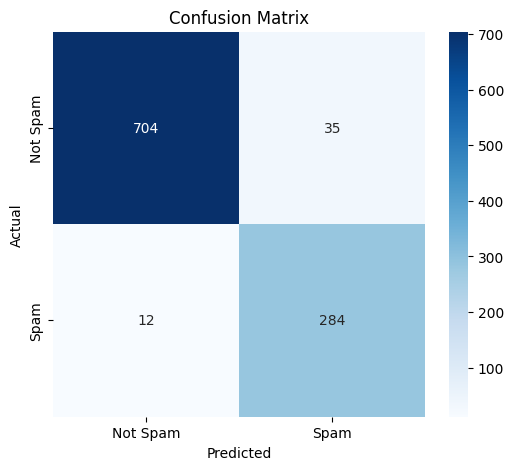


 INTERACTIVE SPAM CHECKER
Instructions: Paste an email text to check it.
Type 'exit' to quit the program.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from collections import Counter


# 1️⃣ LOAD AND PREPARE DATA

print("Loading dataset...")
data = pd.read_csv("emails.csv")

# Drop the ID column and separate features (X) from the target (y)
# The dataset has 3000 word-count columns and one 'Prediction' column
X = data.drop(columns=['Email No.', 'Prediction'])
y = data['Prediction']
word_features = X.columns.tolist()  # The list of 3000 words used as features


# 2️⃣ TRAIN THE MODEL

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Multinomial Naive Bayes model...")
model = MultinomialNB()
model.fit(X_train, y_train)


# 3️⃣ EVALUATION

y_pred = model.predict(X_test)
print(f"\n Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\n Detailed Classification Report:")
print(classification_report(y_test, y_pred))

# Generate and save a Confusion Matrix plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Spam', 'Spam'], 
            yticklabels=['Not Spam', 'Spam'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# 4️⃣ PREDICTION FUNCTION

def predict_email(text):
    """
    Converts raw text into the word-count format the model expects.
    """
    # 1. Clean and count words in the input text
    text_words = text.lower().split()
    word_counts = Counter(text_words)
    
    # 2. Map those counts to the 3000 specific words from the CSV
    counts = [word_counts[word.lower()] for word in word_features]
    
    # 3. Create a DataFrame with feature names to avoid warnings
    input_df = pd.DataFrame([counts], columns=word_features)
    
    # 4. Predict
    prediction = model.predict(input_df)[0]
    return "SPAM" if prediction == 1 else "NOT SPAM"


# 5️⃣ INTERACTIVE USER INTERFACE


print("\n" + "="*40)
print(" INTERACTIVE SPAM CHECKER")
print("="*40)
print("Instructions: Paste an email text to check it.")
print("Type 'exit' to quit the program.")

while True:
    user_input = input("\nEnter email content: ").strip()
    
    if user_input.lower() == 'exit':
        print("Closing program...")
        break
        
    if not user_input:
        print("Please enter some text to analyze.")
        continue
    
    result = predict_email(user_input)
    print(f"Prediction Result: {result}")